# Lecture 3 — Class Exercise
## Line Charts & Slopegraphs: CO2 Emissions

> **Push to:** `week03/lecture03_exercise.ipynb` in your GitHub repo

### Remember:
1. No spaghetti — multiple lines must use grey + single highlight
2. Remove clutter: no chart borders, no heavy gridlines, no legend if you can label directly
3. Insight title — states the finding, not the topic
4. Carry forward from Lecture 2: white background, Arial font, professional quality


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Dataset: CO2 Emissions by Country 2000-2022
# Source: Our World in Data (https://ourworldindata.org/co2-emissions)
df = pd.read_csv('../data/co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())


Loaded: 345 rows | Countries: 15 | Years: 2000-2022
         Country         Region  Year  CO2_Mt  CO2_per_capita
0  United States  North America  2000  5857.6            1.32
1  United States  North America  2001  5724.0            1.26
2  United States  North America  2002  5652.8            1.11
3  United States  North America  2003  5592.8            1.29
4  United States  North America  2004  5743.2            1.12


In [2]:
# Explore before building

print("Countries:", df['Country'].unique())
print("\nCO2 range:", df['CO2_Mt'].min(), "to", df['CO2_Mt'].max(), "Mt")
print("\nRegional averages (2022):")
print(df[df['Year']==2022].groupby('Region')['CO2_Mt'].mean().sort_values(ascending=False).round(1))


Countries: ['United States' 'China' 'India' 'Germany' 'United Kingdom' 'France'
 'Brazil' 'Japan' 'Canada' 'Australia' 'South Korea' 'Russia'
 'South Africa' 'Mexico' 'Indonesia']

CO2 range: 125.3 to 12409.5 Mt

Regional averages (2022):
Region
Asia             3531.1
North America    2393.8
Latin America     629.2
Africa            534.4
Europe            496.5
Oceania           493.7
Name: CO2_Mt, dtype: float64


---
## Task 1 — Multi-Series Line Chart with Highlight

**What to build:** A line chart showing CO2 emissions over time for **all Asian countries** in the dataset, with one country highlighted.

**Requirements:**
- All countries shown (for context), but only **one highlighted in colour** — your choice which
- All other lines in grey (#DDDDDD), thinner
- Highlighted country **labelled directly** at the end of its line (not in a legend)
- Insight title that names the highlighted country and its story

> 💡 `df[df['Region'] == 'Asia']` to filter; use `go.Figure()` with a loop for per-country control


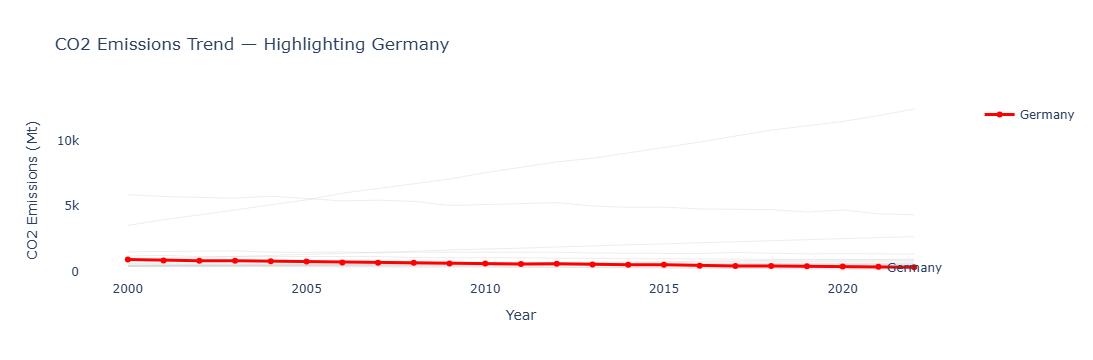

In [6]:
# Task 1 — Multi-series line with highlight
# YOUR CODE HERE
import plotly.graph_objects as go

# Step 1: Aggregate CO2 emissions by Country & Year
country_trend = df.groupby(['Country', 'Year'])['CO2_Mt'].sum().reset_index()

highlight_country = "Germany"   

fig = go.Figure()

for country in country_trend['Country'].unique():
    country_data = country_trend[country_trend['Country'] == country]
    
    if country != highlight_country:
        fig.add_trace(go.Scatter(
            x=country_data['Year'],
            y=country_data['CO2_Mt'],
            mode='lines',
            line=dict(color='lightgray', width=1),
            opacity=0.4,
            showlegend=False
        ))

highlight_data = country_trend[country_trend['Country'] == highlight_country]

fig.add_trace(go.Scatter(
    x=highlight_data['Year'],
    y=highlight_data['CO2_Mt'],
    mode='lines+markers',
    line=dict(color='red', width=3),
    name=highlight_country
))

fig.add_annotation(
    x=highlight_data['Year'].max(),
    y=highlight_data['CO2_Mt'].iloc[-1],
    text=highlight_country,
    showarrow=False
)

fig.update_layout(
    title=f"CO2 Emissions Trend — Highlighting {highlight_country}",
    xaxis_title="Year",
    yaxis_title="CO2 Emissions (Mt)",
    plot_bgcolor='white'
)

fig.show()

---
## Task 2 — Slopegraph: Regional Change 2000 vs 2022

**What to build:** A slopegraph comparing **average regional CO2 emissions** between 2000 and 2022.

**Requirements:**
- One line per region (not per country — aggregate first)
- Colour: regions that increased = one colour; decreased = another
- Values labelled at both ends of each line
- No y-axis tick labels (the endpoint labels make them redundant)
- Insight title stating which regions moved most

> 💡 `df.groupby(['Region','Year'])['CO2_Mt'].mean().reset_index()` then filter to 2000 and 2022


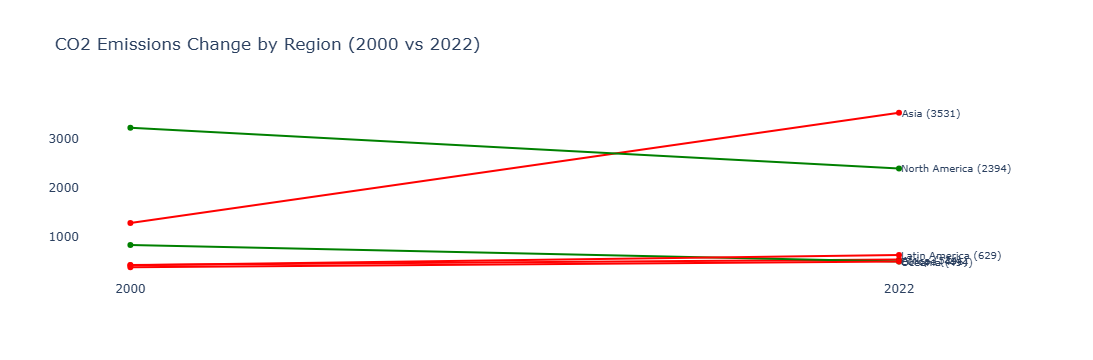

In [5]:
# Task 2 — Slopegraph: regional averages
# YOUR CODE HERE
regional_avg = df.groupby(['Region', 'Year'])['CO2_Mt'].mean().reset_index()

slope_df = regional_avg[regional_avg['Year'].isin([2000, 2022])]

pivot_df = slope_df.pivot(index='Region', columns='Year', values='CO2_Mt').reset_index()
pivot_df.columns = ['Region', 'CO2_2000', 'CO2_2022']

pivot_df['Change'] = pivot_df['CO2_2022'] - pivot_df['CO2_2000']
pivot_df['Trend'] = pivot_df['Change'].apply(lambda x: 'Increase' if x > 0 else 'Decrease')

import plotly.graph_objects as go

fig = go.Figure()

for _, row in pivot_df.iterrows():
    color = 'red' if row['Trend'] == 'Increase' else 'green'
    
    fig.add_trace(go.Scatter(
        x=[2000, 2022],
        y=[row['CO2_2000'], row['CO2_2022']],
        mode='lines+markers',
        line=dict(color=color, width=2),
        showlegend=False
    ))

    fig.add_annotation(
        x=2022,
        y=row['CO2_2022'],
        text=f"{row['Region']} ({row['CO2_2022']:.0f})",
        showarrow=False,
        xanchor='left',
        yanchor='middle',
        font=dict(size=10)
    )

fig.update_layout(
    title="CO2 Emissions Change by Region (2000 vs 2022)",
    xaxis=dict(tickvals=[2000, 2022], showgrid=False),
    yaxis=dict(showgrid=False),
    plot_bgcolor='white'
)

fig.show()